In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('../data/raw/credit_card_fraud_2026.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (20000, 26)


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,11,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,12,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,13,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,14,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,15,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


In [2]:
df.info


<bound method DataFrame.info of        transaction_id  amount_usd merchant_category   card_type        auth_method channel    device_type  is_foreign_transaction  hours_since_last_txn  txn_count_last_24h  distance_from_home_km  \
0                  11       42.86       Restaurants        Visa                OTP  Online  Android Phone                   False                 13.54                   2                  22.35   
1                  12        4.75     Online Retail  Mastercard          3D Secure  Online  Android Phone                   False                  0.71                   2                  35.28   
2                  13       77.18         Groceries  Mastercard          3D Secure  Online            Mac                   False                  0.35                   5                   9.82   
3                  14        1.69         Streaming        Visa  No Authentication     POS  Android Phone                   False                  3.42                   6     

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,20000.0,10010.500000,5773.647028,11.00,5010.7500,10010.500,15010.2500,20010.00
amount_usd,20000.0,132.424597,256.963666,1.00,26.2350,57.510,131.7525,6872.69
hours_since_last_txn,20000.0,8.950827,8.838745,0.01,2.5900,6.210,12.4325,87.05
txn_count_last_24h,20000.0,3.191650,1.779544,0.00,2.0000,3.000,4.0000,12.00
distance_from_home_km,20000.0,22.139525,22.120960,0.00,6.3375,15.505,30.8200,216.19
card_age_months,20000.0,46.937550,6.768577,22.00,42.0000,47.000,51.0000,74.00
customer_age,20000.0,49.669400,18.494032,18.00,34.0000,50.000,66.0000,81.00
account_balance_usd,20000.0,3316.662598,4350.720948,52.05,1019.1400,2007.685,3944.1200,127125.86
cvv_retry_count,20000.0,0.181300,0.422302,0.00,0.0000,0.000,0.0000,3.00
velocity_score,20000.0,19.807735,12.366301,0.00,10.7000,18.800,27.6000,74.40


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)

missing_df[missing_df['missing_count'] > 0]
print(missing_df)

                              missing_count  missing_pct
transaction_id                            0          0.0
amount_usd                                0          0.0
prior_disputes                            0          0.0
merchant_risk_score                       0          0.0
is_ai_generated_scam_attempt              0          0.0
day_of_week                               0          0.0
time_of_day_hour                          0          0.0
velocity_score                            0          0.0
cvv_retry_count                           0          0.0
billing_shipping_mismatch                 0          0.0
ip_country_mismatch                       0          0.0
used_vpn                                  0          0.0
is_new_merchant                           0          0.0
account_balance_usd                       0          0.0
customer_age                              0          0.0
card_age_months                           0          0.0
distance_from_home_km          

In [5]:
dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes}")

id_dupes = df['transaction_id'].duplicated().sum()
print(f"Duplicate transaction_ids: {id_dupes}")

Fully duplicated rows: 0
Duplicate transaction_ids: 0


In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

Categorical columns: ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']

--- merchant_category (12 unique) ---
merchant_category
Online Retail      3416
Groceries          3242
Restaurants        2534
Electronics        2032
Fuel               1565
Travel             1420
Utilities          1330
Healthcare         1237
Gaming             1036
Streaming          1010
Gift Cards          617
Crypto Exchange     561
Name: count, dtype: int64

--- card_type (5 unique) ---
card_type
Visa          8417
Mastercard    6629
Amex          2135
RuPay         1796
Discover      1023
Name: count, dtype: int64

--- auth_method (5 unique) ---
auth_method
3D Secure            5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64

--- channel (5 unique) ---
channel
Online         6810
POS            5191
Contactless    3400
In-App         3225
ATM            1374
Name: count, dtype: int64

--- devi

In [7]:
binary_cols = [
    'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
    'ip_country_mismatch', 'billing_shipping_mismatch',
    'is_ai_generated_scam_attempt', 'is_fraud'
]

for col in binary_cols:
    print(f"{col}: {sorted(df[col].unique())}")

is_foreign_transaction: [np.False_, np.True_]
is_new_merchant: [np.False_, np.True_]
used_vpn: [np.False_, np.True_]
ip_country_mismatch: [np.False_, np.True_]
billing_shipping_mismatch: [np.False_, np.True_]
is_ai_generated_scam_attempt: [np.False_, np.True_]
is_fraud: [np.int64(0), np.int64(1)]


Counts:
is_fraud
0    19661
1      339
Name: count, dtype: int64

Percentages:
is_fraud
0    98.3
1     1.7
Name: proportion, dtype: float64


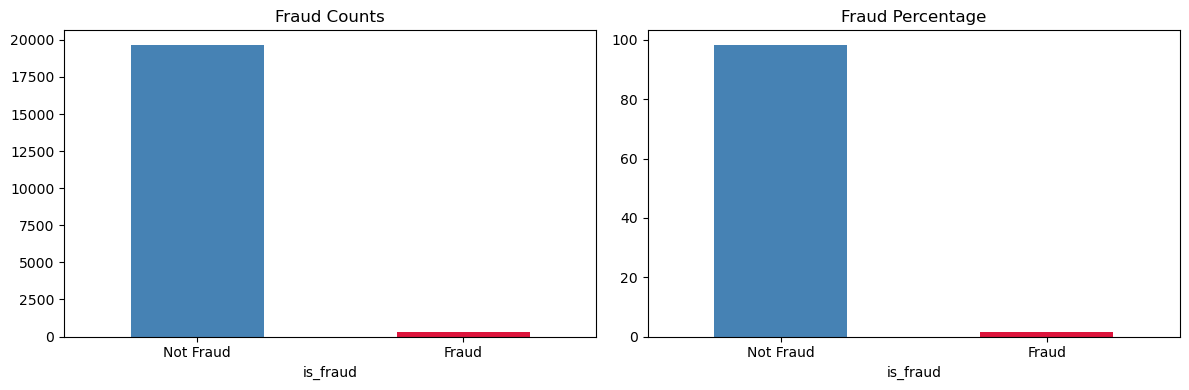

In [8]:
target_counts = df['is_fraud'].value_counts()
target_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_pct.round(2))

# Visual
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=ax[0], color=['steelblue', 'crimson'])
ax[0].set_title('Fraud Counts')
ax[0].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)

target_pct.plot(kind='bar', ax=ax[1], color=['steelblue', 'crimson'])
ax[1].set_title('Fraud Percentage')
ax[1].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_fraud', 'transaction_id'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"Test fraud rate:  {y_test.mean():.4f}")

Train: (16000, 24), Test: (4000, 24)
Train fraud rate: 0.0169
Test fraud rate:  0.0170


## Data Dictionary

| Column | Type | Description | Fraud-Relevance Hypothesis |
|--------|------|-------------|---------------------------|
| transaction_id | int | Unique transaction identifier | Drop before modeling (leakage risk) |
| amount_usd | float | Transaction amount in USD | Fraudsters may test small amounts first, then large |
| merchant_category | cat | Type of merchant | Some categories (crypto, travel) may have higher fraud |
| card_type | cat | Credit/debit card brand | Possibly neutral |
| auth_method | cat | Authentication method used | Weak auth → more fraud |
| channel | cat | Online / POS / ATM | Online likely higher fraud |
| device_type | cat | Device used | New/unknown device → more fraud |
| is_foreign_transaction | binary | Transaction outside home country | Strong fraud signal |
| hours_since_last_txn | float | Time since customer's previous txn | Very short gaps → velocity attack |
| txn_count_last_24h | int | Transactions in last 24h | High count → fraud pattern |
| distance_from_home_km | float | Distance from home location | Sudden large distance → fraud |
| card_age_months | int | Age of card | New cards may be riskier |
| customer_age | int | Age of customer | Fraud may target certain demographics |
| account_balance_usd | float | Current account balance | Low balance + large txn → suspicious |
| is_new_merchant | binary | First time at this merchant | New merchants → higher risk |
| used_vpn | binary | VPN detected | Strong fraud signal |
| ip_country_mismatch | binary | IP country ≠ card country | Strong fraud signal |
| billing_shipping_mismatch | binary | Billing ≠ shipping address | Classic fraud signal |
| cvv_retry_count | int | Failed CVV attempts | Multiple retries → fraud |
| velocity_score | float | Internal velocity score | Likely strong predictor |
| time_of_day_hour | int | Hour of day (0–23) | Fraud may cluster at night |
| day_of_week | cat | Day of week | Weekend patterns |
| is_ai_generated_scam_attempt | binary | AI-generated scam detected | Modern fraud signal |
| merchant_risk_score | float | Merchant risk score | Higher → more fraud |
| prior_disputes | int | Customer's past disputes | Repeat offenders |
| is_fraud | binary | **TARGET** | 1 = fraud, 0 = legitimate |

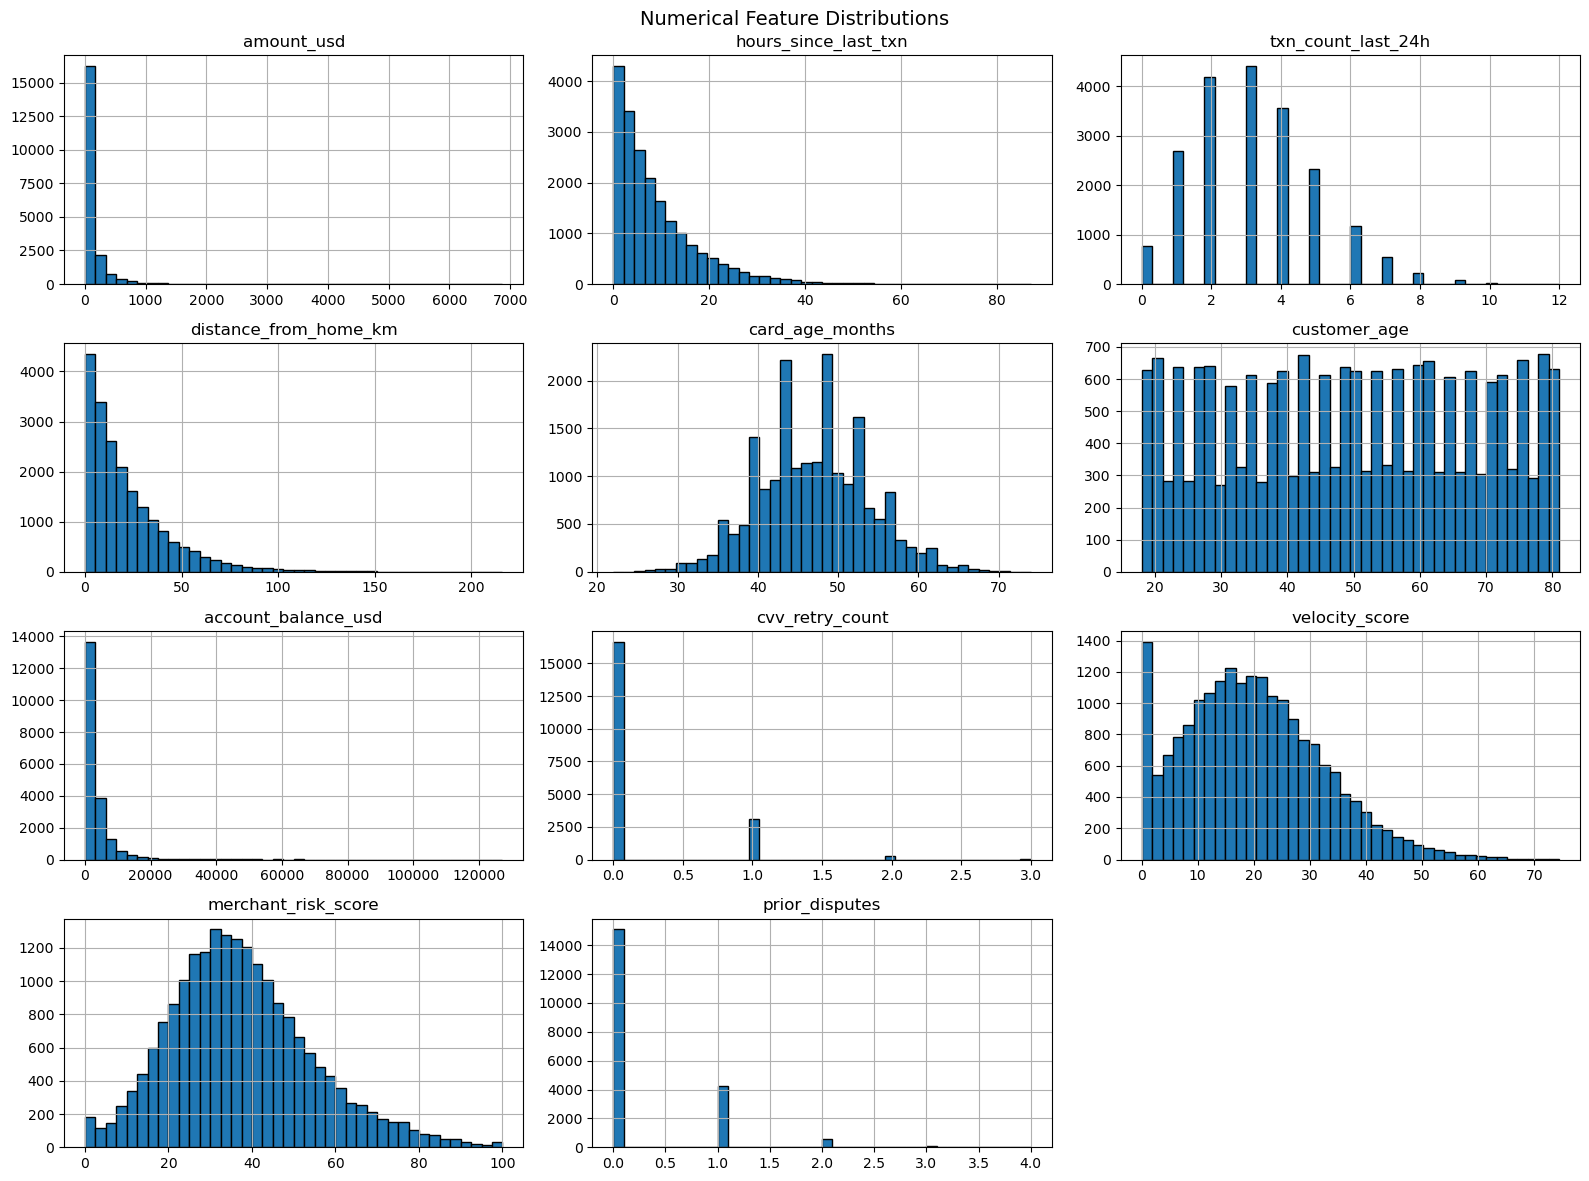

In [10]:
num_cols = [
    'amount_usd', 'hours_since_last_txn', 'txn_count_last_24h',
    'distance_from_home_km', 'card_age_months', 'customer_age',
    'account_balance_usd', 'cvv_retry_count', 'velocity_score',
    'merchant_risk_score', 'prior_disputes'
]

df[num_cols].hist(figsize=(16, 12), bins=40, edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
comparison = df.groupby('is_fraud')[num_cols].agg(['mean', 'median']).T
comparison.columns = ['Non_Fraud', 'Fraud']
comparison['mean_ratio'] = (comparison['Fraud'] / comparison['Non_Fraud']).round(2)
comparison

Non_Fraud        Fraud  mean_ratio
amount_usd            mean     131.582739   181.249853        1.38
                      median    57.350000    69.770000        1.22
hours_since_last_txn  mean       8.984251     7.012389        0.78
                      median     6.230000     4.270000        0.69
txn_count_last_24h    mean       3.177661     4.002950        1.26
                      median     3.000000     4.000000        1.33
distance_from_home_km mean      22.151991    21.416490        0.97
                      median    15.500000    15.610000        1.01
card_age_months       mean      46.948273    46.315634        0.99
                      median    47.000000    46.000000        0.98
customer_age          mean      49.621942    52.421829        1.06
                      median    50.000000    55.000000        1.10
account_balance_usd   mean    3314.165282  3461.499558        1.04
                      median  2005.950000  2115.470000        1.05
cvv_retry_count       mean       0.172677     0.681416        3.95
                      median     0.000000     1.000000         inf
velocity_score        mean      19.649814    28.966667        1.47
                      median    18.700000    27.700000        1.48
merchant_risk_score   mean      37.159158    51.391150        1.38
                      median    35.500000    48.700000        1.37
prior_disputes        mean       0.279589     0.377581        1.35
                      median     0.000000     0.000000         NaN

In [14]:
binary_cols = [
    'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
    'ip_country_mismatch', 'billing_shipping_mismatch',
    'is_ai_generated_scam_attempt'
]

for col in binary_cols:
    rate = df.groupby(col)['is_fraud'].mean() * 100
    print(f"--- {col} ---")
    print(rate.round(3))
    print()

--- is_foreign_transaction ---
is_foreign_transaction
False    1.418
True     5.887
Name: is_fraud, dtype: float64

--- is_new_merchant ---
is_new_merchant
False    1.156
True     3.499
Name: is_fraud, dtype: float64

--- used_vpn ---
used_vpn
False    1.436
True     4.377
Name: is_fraud, dtype: float64

--- ip_country_mismatch ---
ip_country_mismatch
False    1.317
True     7.804
Name: is_fraud, dtype: float64

--- billing_shipping_mismatch ---
billing_shipping_mismatch
False    1.417
True     7.789
Name: is_fraud, dtype: float64

--- is_ai_generated_scam_attempt ---
is_ai_generated_scam_attempt
False    1.554
True     9.067
Name: is_fraud, dtype: float64



In [15]:
cat_cols = ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'day_of_week']

for col in cat_cols:
    print(f"--- {col} ---")
    fraud_rate = df.groupby(col)['is_fraud'].agg(['count', 'mean'])
    fraud_rate['mean'] = (fraud_rate['mean'] * 100).round(2)
    fraud_rate.columns = ['count', 'fraud_rate_%']
    print(fraud_rate.sort_values('fraud_rate_%', ascending=False))
    print()

--- merchant_category ---
                   count  fraud_rate_%
merchant_category                     
Crypto Exchange      561          4.99
Gift Cards           617          4.38
Gaming              1036          3.67
Electronics         2032          2.36
Streaming           1010          2.08
Utilities           1330          1.88
Healthcare          1237          1.29
Groceries           3242          1.23
Fuel                1565          1.21
Restaurants         2534          1.14
Travel              1420          1.13
Online Retail       3416          0.94

--- card_type ---
            count  fraud_rate_%
card_type                      
Amex         2135          2.01
Discover     1023          1.96
Visa         8417          1.78
Mastercard   6629          1.54
RuPay        1796          1.34

--- auth_method ---
                   count  fraud_rate_%
auth_method                           
No Authentication   2388          4.44
OTP                 4792          1.57
3D Secur

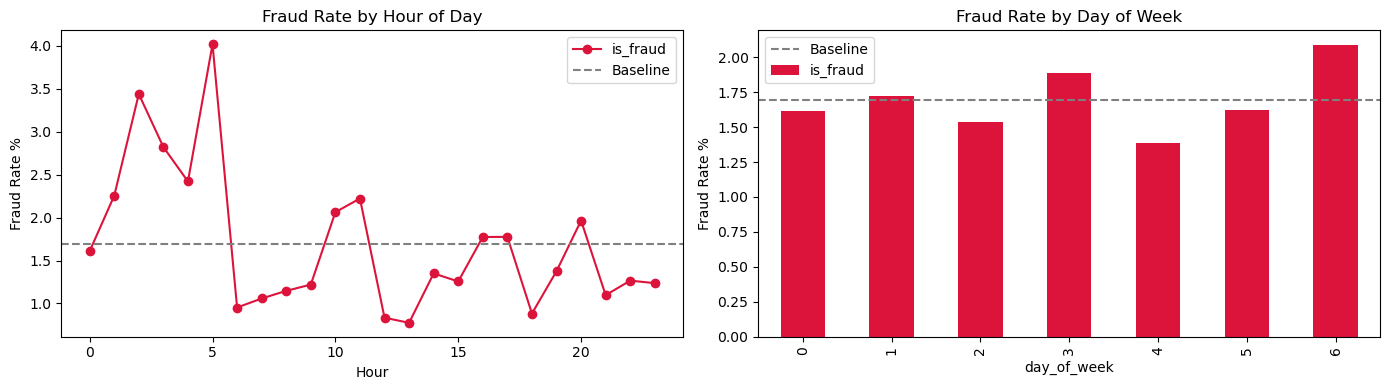

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By hour
hour_fraud = df.groupby('time_of_day_hour')['is_fraud'].mean() * 100
hour_fraud.plot(ax=axes[0], marker='o', color='crimson')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate %')
axes[0].axhline(df['is_fraud'].mean() * 100, ls='--', color='gray', label='Baseline')
axes[0].legend()

# By day
day_fraud = df.groupby('day_of_week')['is_fraud'].mean() * 100
day_fraud.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_ylabel('Fraud Rate %')
axes[1].axhline(df['is_fraud'].mean() * 100, ls='--', color='gray', label='Baseline')
axes[1].legend()

plt.tight_layout()
plt.show()

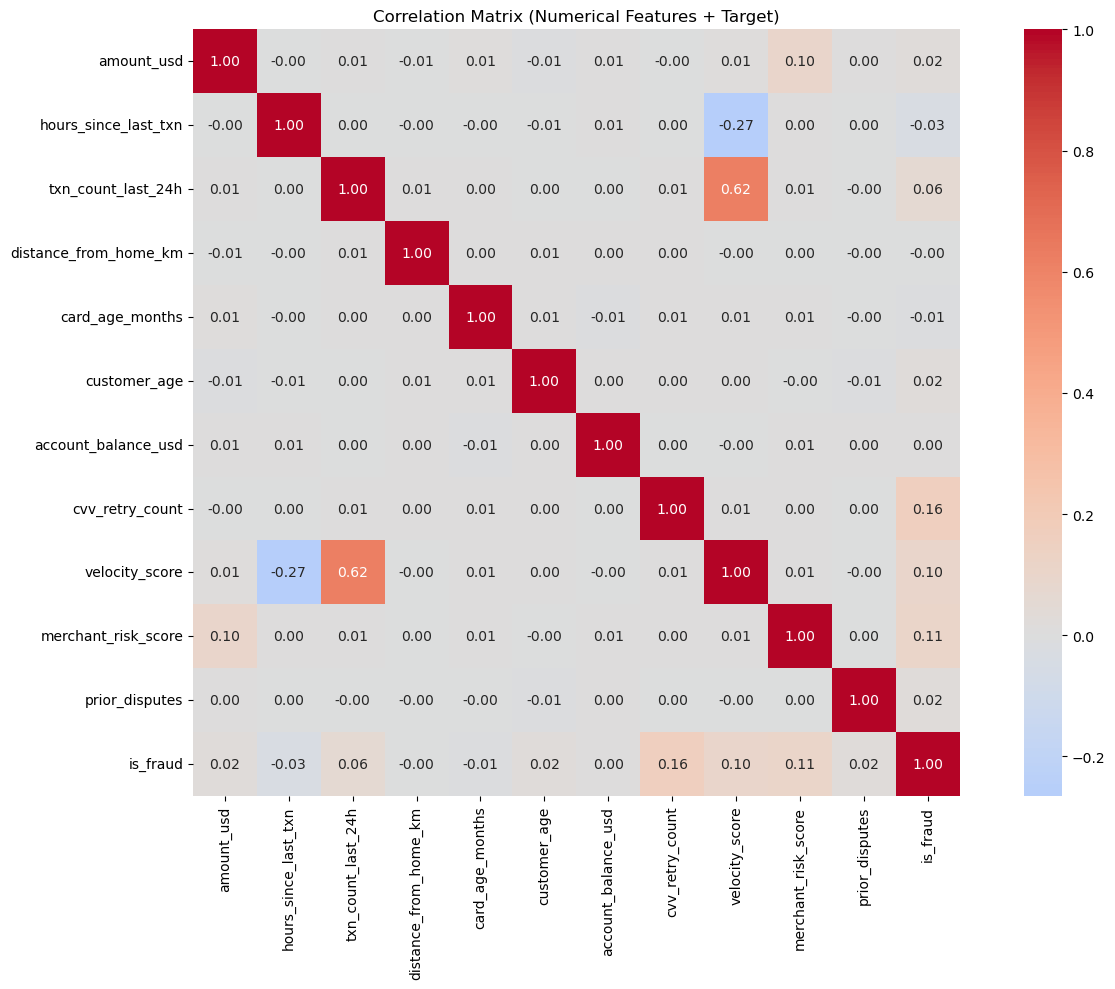

In [17]:
plt.figure(figsize=(14, 10))
corr = df[num_cols + ['is_fraud']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix (Numerical Features + Target)')
plt.tight_layout()
plt.show()

## Data Dictionary — Day 3 Findings

| Column | Type | Range/Values | Fraud Signal | Notes |
|--------|------|--------------|--------------|-------|
| amount_usd | float | 0.xx – xxxx | mean ratio X.X | Right-skewed |
| merchant_category | cat | 6 values | X% in "X" | ... |
| used_vpn | binary | 0/1 | X% when 1 | Strong / weak |

- There is high difference between mean of Fraud and Non-Fraud in amount_usd 
- There is high difference between mean of Fraud and Non-Fraud in cvv_retry_count
- There is high difference between mean of Fraud and Non-Fraud in velocity_score

**We can conclude that these are the features where the fraud transaction mostly takes place**


